In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


In [3]:
df = pd.read_csv('dataset/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
le = LabelEncoder()
df['age'] = le.fit_transform(df['age'])
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])


In [6]:
x = df.drop(columns='charges',axis=1)
y = df['charges']
x.head()

,age,sex,bmi,children,smoker,region
0,1,0,27.900,0,1,3
1,0,1,33.770,1,0,2
2,10,1,33.000,3,0,2
3,15,1,22.705,0,0,1
4,14,1,28.880,0,0,1


In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
models = {
    "Linear regression": LinearRegression(),
    "Ridge regression" : Ridge(),
    "Lasso regression" : Lasso(),
    "DecisionTree Regressor" : DecisionTreeRegressor(),
    "RandomForest Regressor" : RandomForestRegressor(),
    "GradientBoosting Regressor" : GradientBoostingRegressor(),
    "Support vector machine" : SVR()
}

In [8]:
results = {}
input_value = []
names = []
col  = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive']

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\

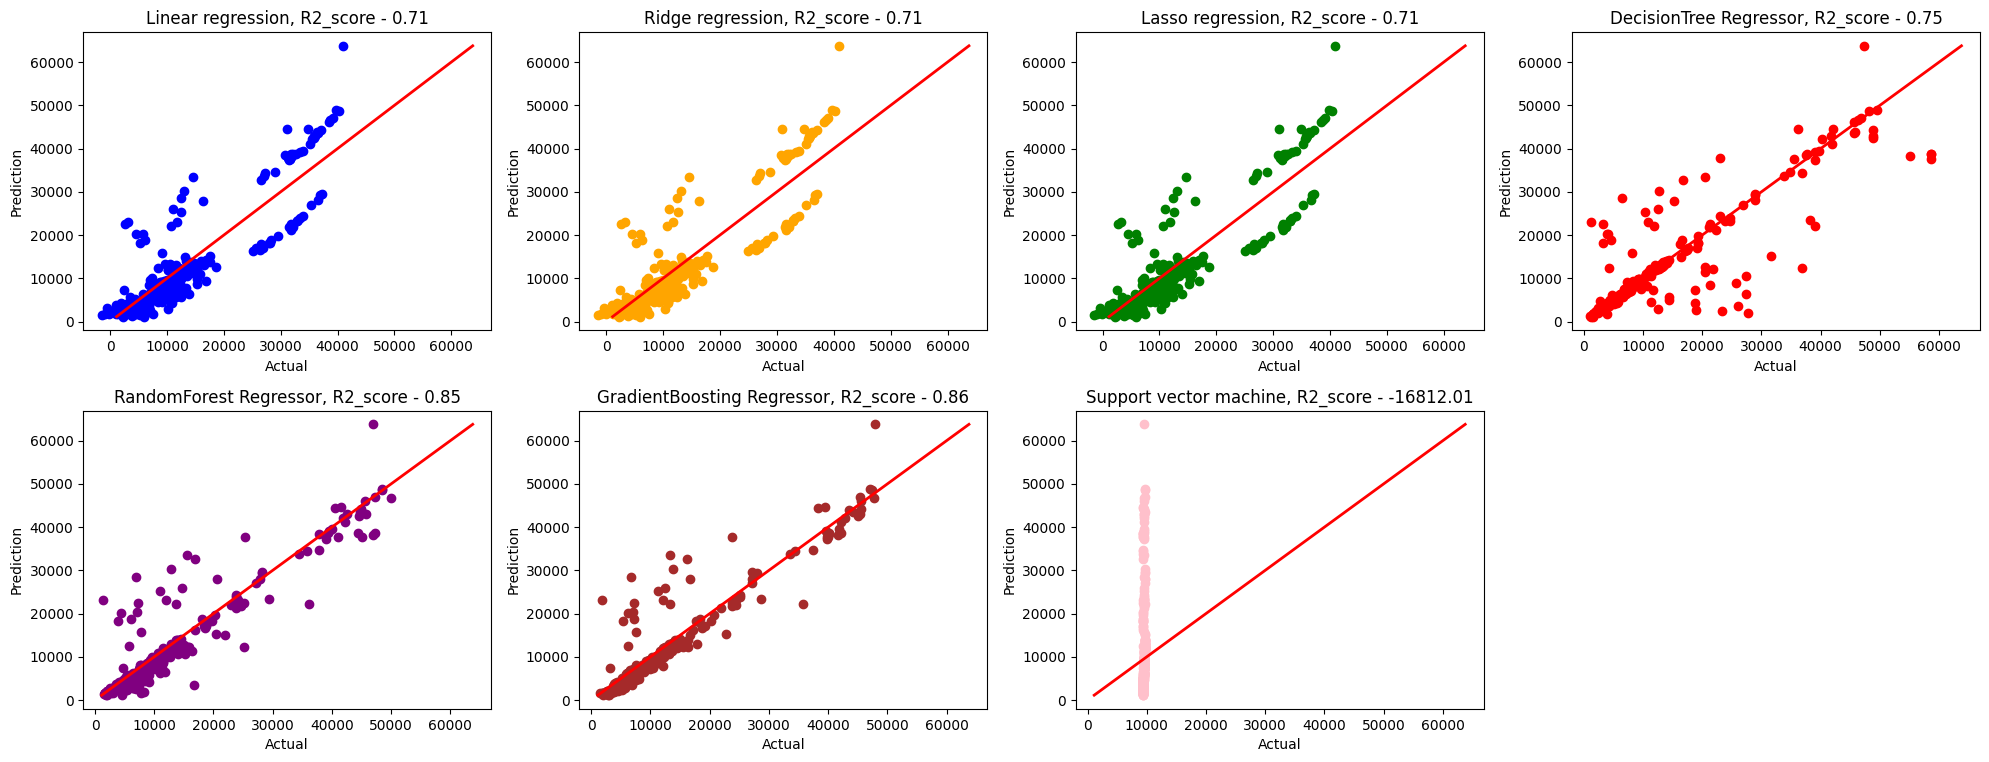

In [11]:
plt.figure(figsize=(20, 30))


for i, (name, model) in enumerate(models.items(), 1):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_pred, y_test)
    mse = mean_squared_error(y_pred, y_test)
    r2 = r2_score(y_pred, y_test)

    a = [[28,	0,	33.770	,1,	1,	3]]
    names.append(name)
    input_value.append(model.predict(a))

    results[name] = {
        'Mean absolute error': mae,
        'Mean square error': mse,
        'R2 score': r2
    }

    plt.subplot(8, 4, i)
    plt.scatter(y_pred, y_test, color=col[i-1])
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
    plt.title(f"{name}, R2_score - {r2:.2f}")
    plt.xlabel("Actual")
    plt.ylabel("Prediction")

plt.tight_layout()
plt.show()


In [ ]:
result_df = pd.DataFrame(results).T
values = pd.DataFrame(input_value).T
name_value = pd.DataFrame(names).T
print(result_df)

values.columns = name_value.iloc[0].tolist()
print("input value reu")
print(values)

                            Mean absolute error  Mean square error  \
Linear regression                   4186.508898       3.363521e+07   
Ridge regression                    4198.141005       3.367579e+07   
Lasso regression                    4187.244900       3.363934e+07   
DecisionTree Regressor              3015.945918       4.316750e+07   
RandomForest Regressor              2491.580501       2.116624e+07   
GradientBoosting Regressor          2447.951558       1.894460e+07   
Support vector machine              8576.508179       1.664117e+08   

                                R2 score  
Linear regression               0.708617  
Ridge regression                0.705498  
Lasso regression                0.708455  
DecisionTree Regressor          0.750982  
RandomForest Regressor          0.854303  
GradientBoosting Regressor      0.861319  
Support vector machine     -16812.009593  
input value reused for prediction
   Linear regression  Ridge regression  Lasso regression  \
0